<a href="https://colab.research.google.com/github/jp-mmoura/PPA_aula3/blob/main/IA_Aula3_Conforto_Termico_Completo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# IA – Aula 3
## Sistema Baseado em Regras – Classificação de Conforto Térmico

**Objetivo:**
- Implementar um sistema simples de regras.
- Classificar conforto térmico com base em temperatura e umidade.
- Comparar abordagem simbólica (regras) com Machine Learning.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from dataclasses import dataclass
from typing import Callable, Dict, List
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import seaborn as sns


---
## Parte 1 – Sistema Baseado em Regras

### Definição das Regras
Regras simplificadas baseadas no diagrama de conforto térmico:

| Condição | Classificação |
|---|---|
| temperatura < 10°C | Muito Frio |
| temperatura > 35°C | Muito Quente |
| umidade < 30% | Muito Seco |
| umidade > 80% | Muito Úmido |
| demais casos | Confortável |


In [2]:
@dataclass
class Rule:
    name: str
    condition: Callable[[Dict], bool]
    label: str

def classify(row, rules: List[Rule]):
    for r in rules:
        if r.condition(row):
            return r.label
    return 'Confortável'

rules = [
    Rule('Muito Frio',   lambda r: r['temperatura'] < 10, 'Muito Frio'),
    Rule('Muito Quente', lambda r: r['temperatura'] > 35, 'Muito Quente'),
    Rule('Muito Seco',   lambda r: r['umidade'] < 30,     'Muito Seco'),
    Rule('Muito Úmido',  lambda r: r['umidade'] > 80,     'Muito Úmido'),
]


### Dataset de Teste (pequeno)


In [3]:
data_teste = pd.DataFrame({
    'temperatura': [5, 22, 40, 28, 18],
    'umidade':     [50, 45, 60, 85, 20]
})

data_teste['classificacao'] = data_teste.apply(lambda row: classify(row, rules), axis=1)
data_teste


,temperatura,umidade,classificacao
0,5,50,Muito Frio
1,22,45,Confortável
2,40,60,Muito Quente
3,28,85,Muito Úmido
4,18,20,Muito Seco


### Visualização do Espaço de Decisão – Sistema de Regras


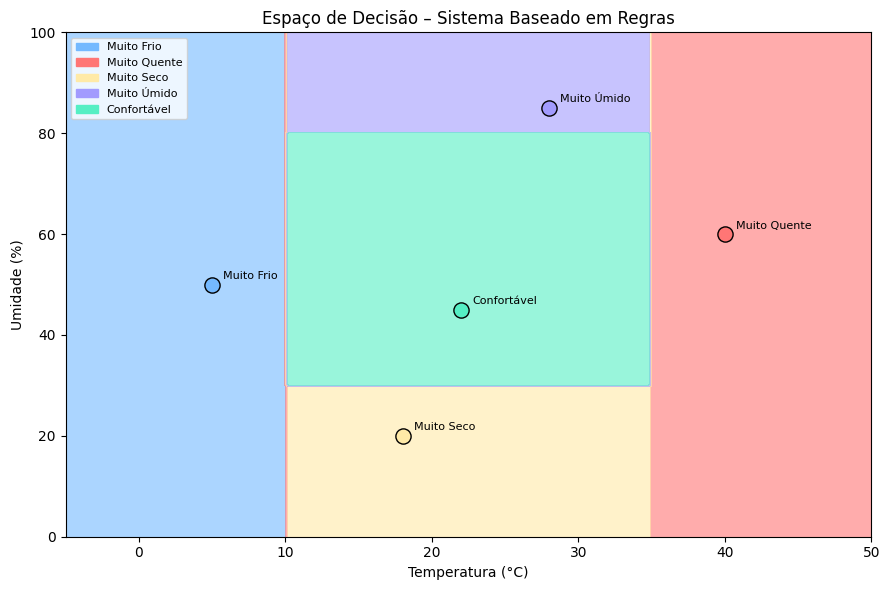

In [4]:
cores = {
    'Muito Frio':   '#74b9ff',
    'Muito Quente': '#ff7675',
    'Muito Seco':   '#ffeaa7',
    'Muito Úmido':  '#a29bfe',
    'Confortável':  '#55efc4'
}

temps = np.linspace(-5, 50, 200)
umids = np.linspace(0, 100, 200)
TT, UU = np.meshgrid(temps, umids)

grid_df = pd.DataFrame({'temperatura': TT.ravel(), 'umidade': UU.ravel()})
grid_df['label'] = grid_df.apply(lambda r: classify(r, rules), axis=1)

label_map = {l: i for i, l in enumerate(cores.keys())}
ZZ = np.array([label_map[l] for l in grid_df['label']]).reshape(TT.shape)

fig, ax = plt.subplots(figsize=(9, 6))
cmap = plt.cm.colors.ListedColormap(list(cores.values()))
ax.contourf(TT, UU, ZZ, levels=[-0.5, 0.5, 1.5, 2.5, 3.5, 4.5], colors=list(cores.values()), alpha=0.6)

# Pontos de teste
for _, row in data_teste.iterrows():
    ax.scatter(row['temperatura'], row['umidade'], color=cores[row['classificacao']],
               edgecolors='black', s=120, zorder=5)
    ax.annotate(row['classificacao'], (row['temperatura'], row['umidade']),
                textcoords='offset points', xytext=(8, 4), fontsize=8)

patches = [mpatches.Patch(color=c, label=l) for l, c in cores.items()]
ax.legend(handles=patches, loc='upper left', fontsize=8)
ax.set_xlabel('Temperatura (°C)')
ax.set_ylabel('Umidade (%)')
ax.set_title('Espaço de Decisão – Sistema Baseado em Regras')
plt.tight_layout()
plt.show()


---
## Parte 2 – Machine Learning com Árvore de Decisão

Vamos gerar um dataset maior usando as próprias regras como **fonte de verdade** (ground truth),  
e então treinar uma `DecisionTreeClassifier` do scikit-learn para aprender o mesmo comportamento.


In [5]:
# Gera 500 amostras aleatórias rotuladas pelas regras
np.random.seed(42)
n = 500

df = pd.DataFrame({
    'temperatura': np.random.uniform(-5, 50, n),
    'umidade':     np.random.uniform(0, 100, n)
})
df['label'] = df.apply(lambda r: classify(r, rules), axis=1)

print('Distribuição das classes:')
print(df['label'].value_counts())
df.head()


Distribuição das classes:
label
Muito Quente    140
Muito Frio      137
Confortável     116
Muito Seco       67
Muito Úmido      40
Name: count, dtype: int64


,temperatura,umidade,label
0,15.599707,69.816171,Confortável
1,47.289287,53.609637,Muito Quente
2,35.259667,30.952762,Muito Quente
3,27.926217,81.379502,Muito Úmido
4,3.581025,68.473117,Muito Frio


In [6]:
X = df[['temperatura', 'umidade']]
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

clf = DecisionTreeClassifier(max_depth=5, random_state=42)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f'Acurácia na base de teste: {acc:.2%}')


Acurácia na base de teste: 100.00%


### Relatório de Classificação


In [7]:
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

 Confortável       1.00      1.00      1.00        29
  Muito Frio       1.00      1.00      1.00        34
Muito Quente       1.00      1.00      1.00        35
  Muito Seco       1.00      1.00      1.00        17
 Muito Úmido       1.00      1.00      1.00        10

    accuracy                           1.00       125
   macro avg       1.00      1.00      1.00       125
weighted avg       1.00      1.00      1.00       125



### Matriz de Confusão


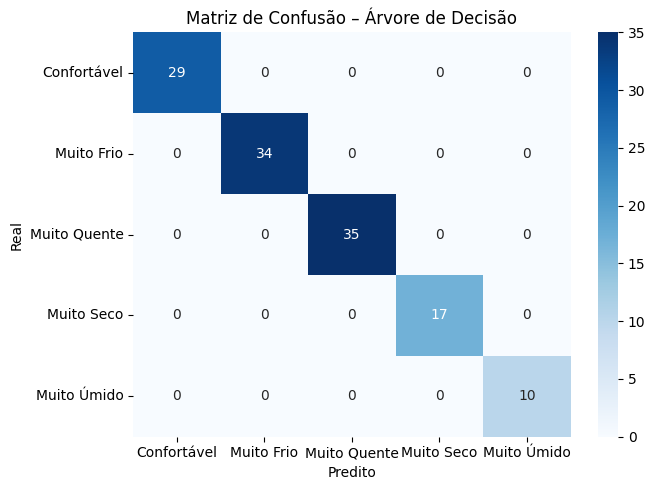

In [8]:
classes = sorted(y.unique())
cm = confusion_matrix(y_test, y_pred, labels=classes)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes, ax=ax)
ax.set_xlabel('Predito')
ax.set_ylabel('Real')
ax.set_title('Matriz de Confusão – Árvore de Decisão')
plt.tight_layout()
plt.show()


### Visualização da Árvore de Decisão


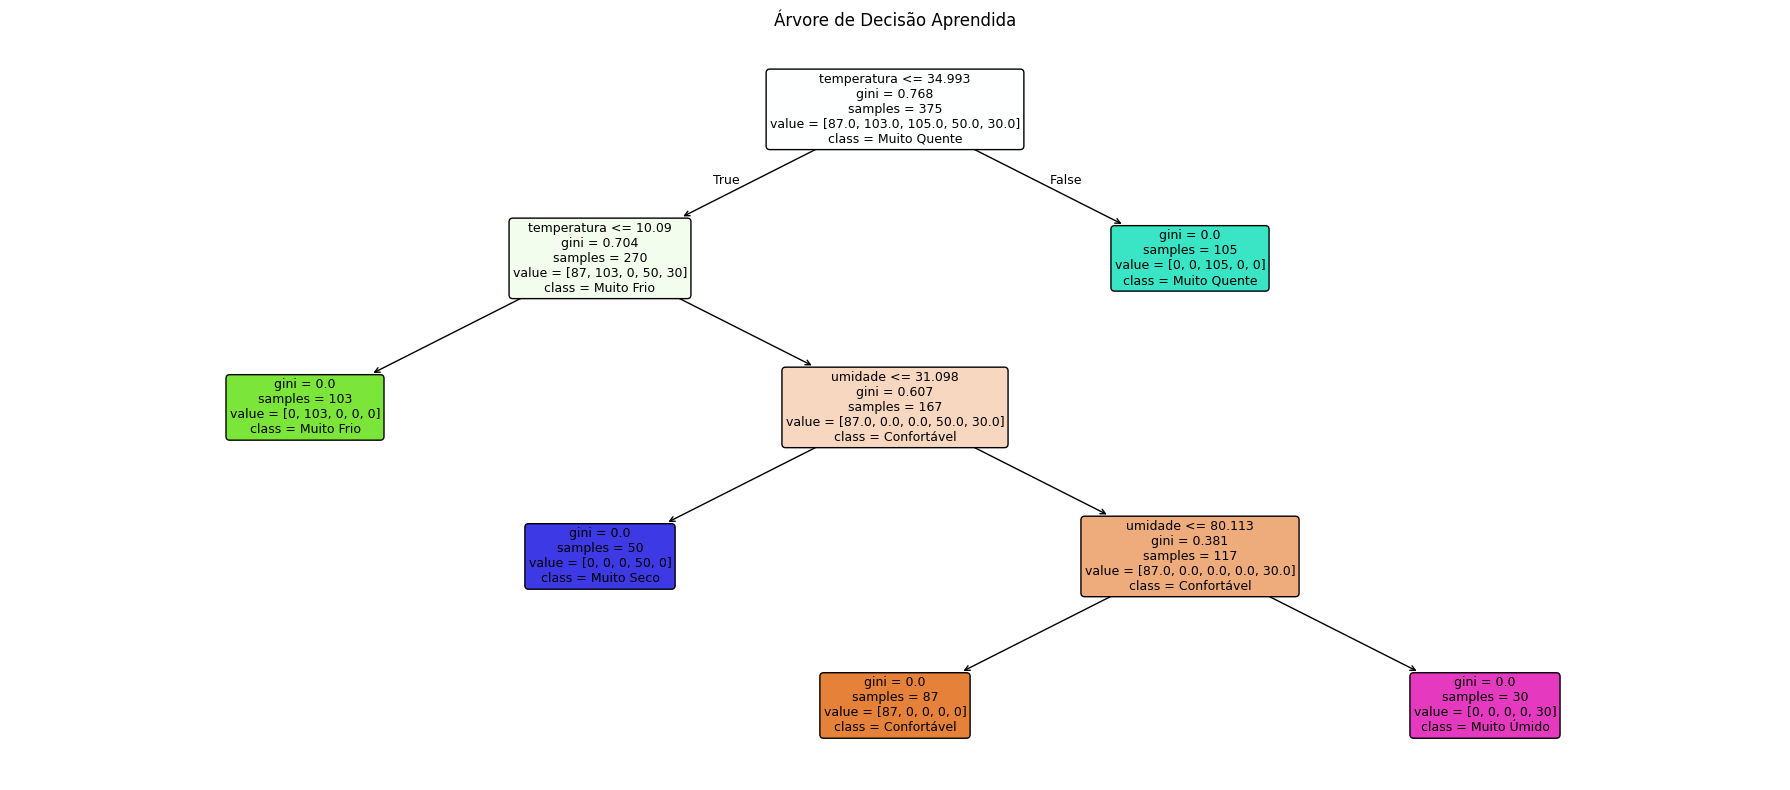

In [9]:
fig, ax = plt.subplots(figsize=(18, 8))
plot_tree(clf, feature_names=['temperatura', 'umidade'],
          class_names=clf.classes_, filled=True, rounded=True,
          fontsize=9, ax=ax)
ax.set_title('Árvore de Decisão Aprendida')
plt.tight_layout()
plt.show()


### Espaço de Decisão – Árvore de Decisão


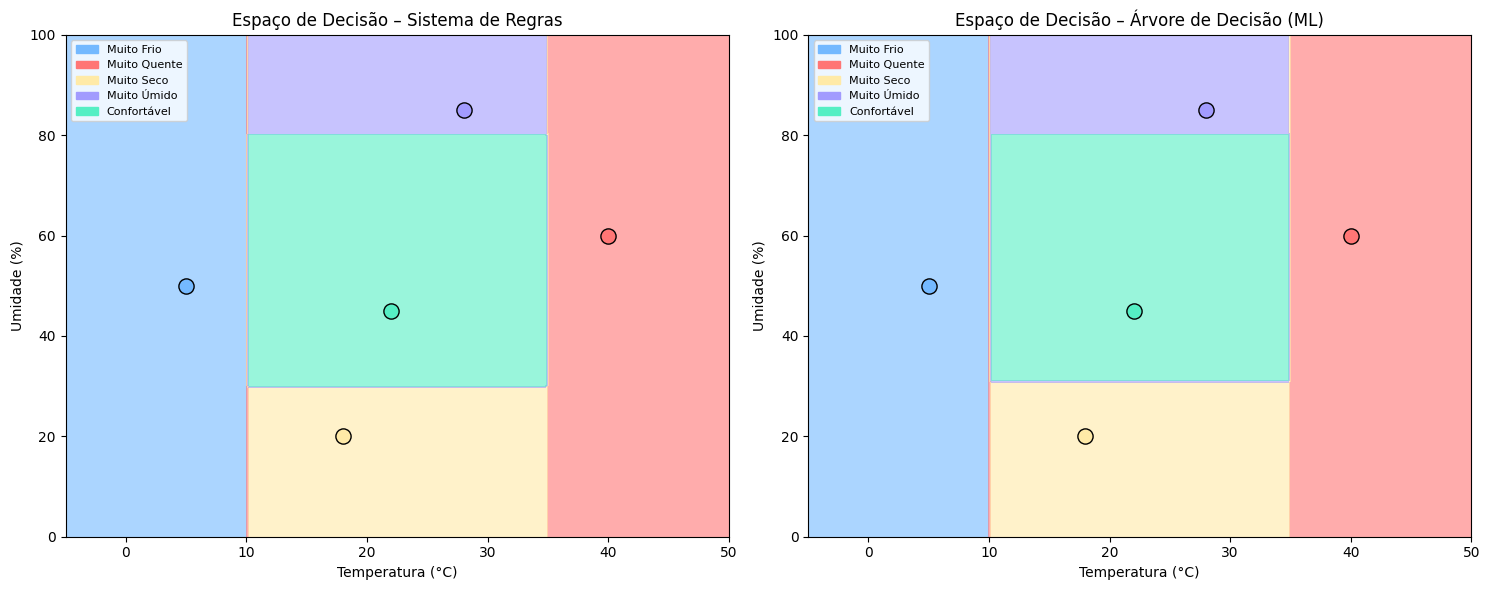

In [10]:
grid_pred = clf.predict(grid_df[['temperatura', 'umidade']])
ZZ_ml = np.array([label_map[l] for l in grid_pred]).reshape(TT.shape)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for ax, ZZ_plot, title in zip(axes,
                               [ZZ, ZZ_ml],
                               ['Sistema de Regras', 'Árvore de Decisão (ML)']):
    ax.contourf(TT, UU, ZZ_plot, levels=[-0.5,0.5,1.5,2.5,3.5,4.5],
                colors=list(cores.values()), alpha=0.6)
    for _, row in data_teste.iterrows():
        ax.scatter(row['temperatura'], row['umidade'],
                   color=cores[row['classificacao']], edgecolors='black', s=120, zorder=5)
    patches = [mpatches.Patch(color=c, label=l) for l, c in cores.items()]
    ax.legend(handles=patches, loc='upper left', fontsize=8)
    ax.set_xlabel('Temperatura (°C)')
    ax.set_ylabel('Umidade (%)')
    ax.set_title(f'Espaço de Decisão – {title}')

plt.tight_layout()
plt.show()


---
## Parte 3 – Comparação: Regras × Machine Learning


In [11]:
# Aplica ambas as abordagens sobre o dataset completo
df['pred_regras'] = df.apply(lambda r: classify(r, rules), axis=1)
df['pred_ml']     = clf.predict(df[['temperatura', 'umidade']])

acc_regras = accuracy_score(df['label'], df['pred_regras'])
acc_ml     = accuracy_score(df['label'], df['pred_ml'])

print(f"Acurácia – Sistema de Regras : {acc_regras:.2%}")
print(f"Acurácia – Árvore de Decisão: {acc_ml:.2%}")

divergencias = df[df['pred_regras'] != df['pred_ml']]
print(f"\nNúmero de divergências entre os dois sistemas: {len(divergencias)}")
divergencias.head()


Acurácia – Sistema de Regras : 100.00%
Acurácia – Árvore de Decisão: 100.00%

Número de divergências entre os dois sistemas: 0


,temperatura,umidade,label,pred_regras,pred_ml


In [12]:
# Tabela comparativa resumida
comparativo = pd.DataFrame({
    'Critério': [
        'Transparência',
        'Interpretabilidade',
        'Escalabilidade',
        'Aprendizado automático',
        'Custo de manutenção',
        'Robustez a dados ruidosos',
        'Necessidade de dados rotulados'
    ],
    'Sistema de Regras': [
        'Alta – regras explícitas',
        'Alta – legível por humanos',
        'Baixa – regras crescem manualmente',
        'Não',
        'Alto',
        'Baixa',
        'Não'
    ],
    'Machine Learning (Árvore)': [
        'Média – estrutura da árvore visível',
        'Média – visualizável até certa profundidade',
        'Alta – aprende fronteiras complexas',
        'Sim',
        'Baixo (após treinamento)',
        'Média a Alta',
        'Sim'
    ]
})
comparativo


,Critério,Sistema de Regras,Machine Learning (Árvore)
0,Transparência,Alta – regras explícitas,Média – estrutura da árvore visível
1,Interpretabilidade,Alta – legível por humanos,Média – visualizável até certa profundidade
2,Escalabilidade,Baixa – regras crescem manualmente,Alta – aprende fronteiras complexas
3,Aprendizado automático,Não,Sim
4,Custo de manutenção,Alto,Baixo (após treinamento)
5,Robustez a dados ruidosos,Baixa,Média a Alta
6,Necessidade de dados rotulados,Não,Sim


---
## Conclusão

- O **sistema de regras** é totalmente transparente e auditável, mas exige esforço manual para cada nova condição.
- A **árvore de decisão** consegue *aprender* as mesmas fronteiras automaticamente a partir dos dados, reproduzindo o comportamento das regras com alta fidelidade.
- Em problemas reais com padrões mais complexos, o ML tende a superar as regras manuais — desde que haja dados de qualidade suficientes.
- A comparação dos espaços de decisão mostra que as duas abordagens produzem regiões quase idênticas quando o modelo ML é treinado com dados gerados pelas próprias regras.
